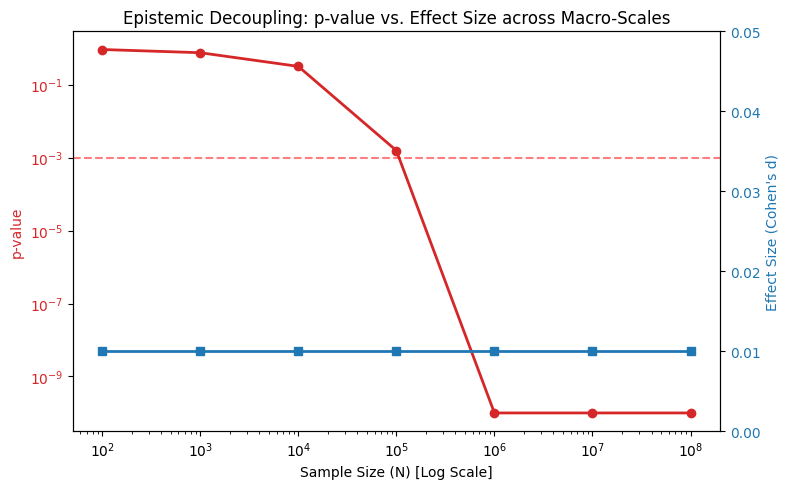

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# パラメータ設定
N_list = np.logspace(2, 8, num=7) # N = 10^2 から 10^8
bias = 0.01  # 極めて微小な同調バイアス
std_dev = 1.0

p_values = []
cohens_d_list = []

# 計算ループ
for N in N_list:
    d = bias / std_dev
    t_stat = d * np.sqrt(N)
    p_val = 2 * (1 - stats.norm.cdf(t_stat))

    p_values.append(max(p_val, 1e-10)) # グラフ描画用に最小値をクリップ
    cohens_d_list.append(d)

# グラフの描画（2軸プロット）
fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = 'tab:red'
ax1.set_xlabel('Sample Size (N) [Log Scale]')
ax1.set_xscale('log')
ax1.set_ylabel('p-value', color=color1)
ax1.plot(N_list, p_values, color=color1, marker='o', linewidth=2, label='p-value')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0.001, color='red', linestyle='--', alpha=0.5, label='Significance Threshold (p=0.001)')
ax1.set_yscale('log')

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel("Effect Size (Cohen's d)", color=color2)
ax2.plot(N_list, cohens_d_list, color=color2, marker='s', linewidth=2, label="Cohen's d")
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 0.05)

plt.title("Epistemic Decoupling: p-value vs. Effect Size across Macro-Scales")
fig.tight_layout()
plt.savefig("fig_epistemic_decoupling.png", dpi=300)
plt.show()